# Anomaly Detection Evaluation

VisA candle 実験の評価結果を横断比較する notebook。

この notebook では以下を確認する。

- image-level 指標
- pixel-level 指標
- category 別の安定性
- threshold curve
- train 正常画像枚数と精度の関係
- 実務観点の比較軸


In [ ]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

CHECKPOINT_ROOT = Path("/workspace/checkpoints/anomaly_detection")
MODEL_RUNS = {
    "padim": CHECKPOINT_ROOT / "padim" / "padim_visa",
    "patchcore": CHECKPOINT_ROOT / "patchcore" / "patchcore_visa",
    "fastflow": CHECKPOINT_ROOT / "fastflow" / "fastflow_visa",
    "stfpm": CHECKPOINT_ROOT / "stfpm" / "stfpm_visa",
    "winclip_zeroshot": CHECKPOINT_ROOT / "winclip_zeroshot" / "visa",
    "winclip_fewshot": CHECKPOINT_ROOT / "winclip_fewshot" / "visa",
}

PRACTICAL_PROFILE = {
    "padim": {
        "training_cost": "low",
        "inference_cost": "medium",
        "ops_fit": "high",
        "fewshot_readiness": "none",
        "strength": "small tuning space and stable classical baseline",
    },
    "patchcore": {
        "training_cost": "high",
        "inference_cost": "medium",
        "ops_fit": "medium",
        "fewshot_readiness": "none",
        "strength": "strong image-level anomaly baseline when data is clean",
    },
    "fastflow": {
        "training_cost": "medium",
        "inference_cost": "medium",
        "ops_fit": "medium",
        "fewshot_readiness": "none",
        "strength": "end-to-end trainable flow model with tunable capacity",
    },
    "stfpm": {
        "training_cost": "medium",
        "inference_cost": "medium",
        "ops_fit": "medium",
        "fewshot_readiness": "none",
        "strength": "teacher-student distillation with interpretable feature gaps",
    },
    "winclip_zeroshot": {
        "training_cost": "none",
        "inference_cost": "high",
        "ops_fit": "high",
        "fewshot_readiness": "zero-shot",
        "strength": "best when onboarding speed matters more than per-site tuning",
    },
    "winclip_fewshot": {
        "training_cost": "low",
        "inference_cost": "high",
        "ops_fit": "medium",
        "fewshot_readiness": "few-shot",
        "strength": "useful when a few trusted normal references are available",
    },
}


In [ ]:

def load_json(path: Path) -> dict:
    return json.loads(path.read_text()) if path.exists() else {}


def load_dataframe(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def best_threshold_point(threshold_df: pd.DataFrame) -> dict:
    if not len(threshold_df) or "f1" not in threshold_df.columns:
        return {}
    row = threshold_df.sort_values("f1", ascending=False).iloc[0]
    return {
        "best_threshold": row.get("threshold"),
        "best_precision": row.get("precision"),
        "best_recall": row.get("recall"),
        "best_f1": row.get("f1"),
    }


def summarize_run(model_name: str, run_root: Path) -> dict:
    experiment_summary = load_json(run_root / "experiment_summary.json")
    test_root = run_root / "best_test_results"
    image_metrics = load_json(test_root / "image_level_metrics.json")
    pixel_metrics = load_json(test_root / "pixel_level_metrics.json")
    threshold_point = best_threshold_point(load_dataframe(test_root / "threshold_curve.csv"))
    train_split = load_dataframe(test_root / "train_split_summary.csv")
    category_metrics = load_dataframe(test_root / "category_metrics.csv")

    best_f1 = threshold_point.get("best_f1", image_metrics.get("best_f1"))
    best_threshold = threshold_point.get("best_threshold", image_metrics.get("best_threshold"))
    row = {
        "model": model_name,
        "run_root": str(run_root),
        "experiment_name": experiment_summary.get("experiment_name"),
        "mode": experiment_summary.get("mode"),
        "best_source": experiment_summary.get("best_source"),
        "best_f1": best_f1,
        "best_precision": threshold_point.get("best_precision"),
        "best_recall": threshold_point.get("best_recall"),
        "best_threshold": best_threshold,
        "image_auroc": image_metrics.get("image_auroc"),
        "image_ap": image_metrics.get("image_ap"),
        "pixel_auroc": pixel_metrics.get("pixel_auroc"),
        "pixel_ap": pixel_metrics.get("pixel_ap"),
        "num_train_normal_images": int(train_split["num_train_normal_images"].sum()) if len(train_split) else None,
        "num_categories": int(category_metrics["category"].nunique()) if len(category_metrics) else 0,
    }
    row.update(PRACTICAL_PROFILE.get(model_name, {}))
    return row


overview_rows = [summarize_run(model_name, run_root) for model_name, run_root in MODEL_RUNS.items()]
overview_df = pd.DataFrame(overview_rows)
overview_df


,model,run_root,experiment_name,mode,best_source,best_f1,best_precision,best_recall,best_threshold,image_auroc,image_ap,pixel_auroc,pixel_ap,num_train_normal_images,num_categories,training_cost,inference_cost,ops_fit,fewshot_readiness,strength
0,padim,/workspace/checkpoints/anomaly_detection/padim...,padim_visa,grid,grid,0.893023,0.834783,0.960000,0.457475,0.941300,0.927859,0.989020,0.183571,720.0,1,low,medium,high,none,small tuning space and stable classical baseline
1,patchcore,/workspace/checkpoints/anomaly_detection/patch...,patchcore_visa,grid,grid,0.932039,0.905660,0.960000,0.478419,0.979700,0.979538,0.992456,0.248929,720.0,1,high,medium,medium,none,strong image-level anomaly baseline when data ...
2,fastflow,/workspace/checkpoints/anomaly_detection/fastf...,fastflow_visa,full,optuna,0.910798,0.858407,0.970000,0.239665,0.967900,0.966605,0.982259,0.115801,NaN,1,medium,medium,medium,none,end-to-end trainable flow model with tunable c...
3,stfpm,/workspace/checkpoints/anomaly_detection/stfpm...,stfpm_visa,full,optuna,0.726531,0.613793,0.890000,0.475921,0.739000,0.694878,0.937689,0.070737,NaN,1,medium,medium,medium,none,teacher-student distillation with interpretabl...
4,winclip_zeroshot,/workspace/checkpoints/anomaly_detection/wincl...,winclip_zeroshot_visa,zero_shot,test,0.773085,0.677541,0.900000,0.499836,0.714229,0.703649,0.729148,0.054212,NaN,12,none,high,high,zero-shot,best when onboarding speed matters more than p...
5,winclip_fewshot,/workspace/checkpoints/anomaly_detection/wincl...,winclip_fewshot_visa,none,train,0.775334,0.683408,0.895833,0.495763,0.789424,0.828074,0.953654,0.226647,NaN,12,low,high,medium,few-shot,useful when a few trusted normal references ar...


In [ ]:

overview_columns = [
    "model",
    "mode",
    "best_source",
    "best_f1",
    "best_precision",
    "best_recall",
    "best_threshold",
    "image_auroc",
    "image_ap",
    "pixel_auroc",
    "pixel_ap",
    "num_train_normal_images",
    "training_cost",
    "inference_cost",
    "ops_fit",
    "fewshot_readiness",
]
display(overview_df[overview_columns].sort_values(by=["best_f1", "best_recall"], ascending=False))


,model,mode,best_source,best_f1,best_precision,best_recall,best_threshold,image_auroc,image_ap,pixel_auroc,pixel_ap,num_train_normal_images,training_cost,inference_cost,ops_fit,fewshot_readiness
1,patchcore,grid,grid,0.932039,0.905660,0.960000,0.478419,0.979700,0.979538,0.992456,0.248929,720.0,high,medium,medium,none
2,fastflow,full,optuna,0.910798,0.858407,0.970000,0.239665,0.967900,0.966605,0.982259,0.115801,NaN,medium,medium,medium,none
0,padim,grid,grid,0.893023,0.834783,0.960000,0.457475,0.941300,0.927859,0.989020,0.183571,720.0,low,medium,high,none
5,winclip_fewshot,none,train,0.775334,0.683408,0.895833,0.495763,0.789424,0.828074,0.953654,0.226647,NaN,low,high,medium,few-shot
4,winclip_zeroshot,zero_shot,test,0.773085,0.677541,0.900000,0.499836,0.714229,0.703649,0.729148,0.054212,NaN,none,high,high,zero-shot
3,stfpm,full,optuna,0.726531,0.613793,0.890000,0.475921,0.739000,0.694878,0.937689,0.070737,NaN,medium,medium,medium,none


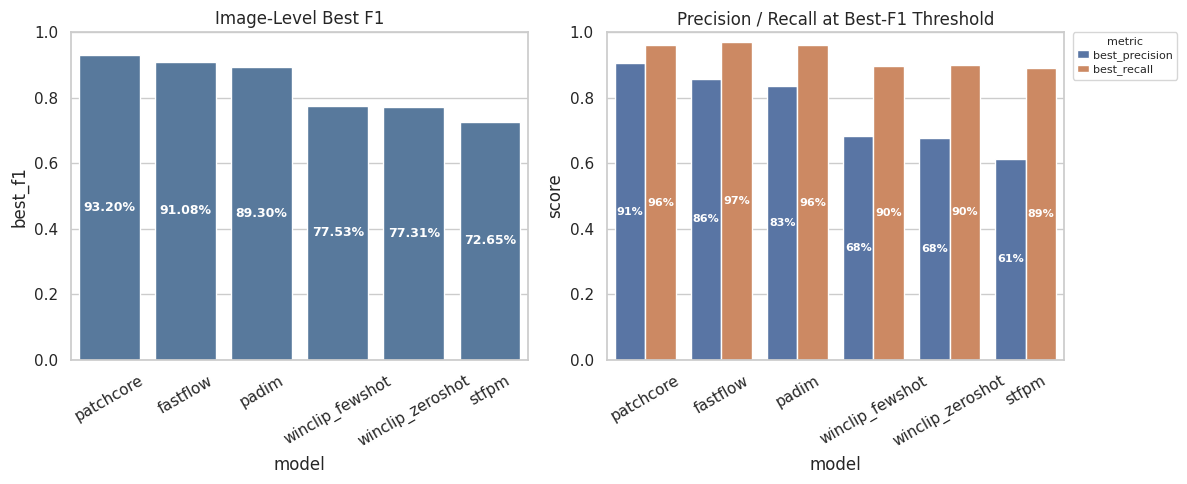

In [ ]:

def annotate_bars_as_percent(ax, *, decimals: int = 2, fontsize: int = 9) -> None:
    for container in ax.containers:
        labels = [f"{bar.get_height() * 100:.{decimals}f}%" if bar.get_height() == bar.get_height() else "" for bar in container]
        ax.bar_label(container, labels=labels, label_type="center", color="white", fontsize=fontsize, fontweight="bold")


plot_df = overview_df.copy()
plot_df = plot_df.sort_values(by="best_f1", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=plot_df, x="model", y="best_f1", ax=axes[0], color="#4C78A8")
axes[0].set_title("Image-Level Best F1")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)
annotate_bars_as_percent(axes[0])

pr_df = plot_df.melt(
    id_vars="model",
    value_vars=["best_precision", "best_recall"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=pr_df, x="model", y="score", hue="metric", ax=axes[1])
axes[1].set_title("Precision / Recall at Best-F1 Threshold")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(
    title="metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=8,
    title_fontsize=8,
    handlelength=1,
    handletextpad=0.4,
    labelspacing=0.3,
)
annotate_bars_as_percent(axes[1], decimals=0, fontsize=8)

plt.tight_layout(rect=(0, 0, 0.86, 1))
plt.show()


In [ ]:

category_frames = []
for model_name, run_root in MODEL_RUNS.items():
    path = run_root / "best_test_results" / "category_metrics.csv"
    df = load_dataframe(path)
    if len(df):
        df["model"] = model_name
        category_frames.append(df)

category_metrics_df = pd.concat(category_frames, ignore_index=True) if category_frames else pd.DataFrame()
category_columns = [
    "model",
    "category",
    "best_f1",
    "best_threshold",
    "image_ap",
    "image_auroc",
    "num_test_examples",
    "positive_ratio",
    "num_train_normal_images",
]
existing_columns = [column for column in category_columns if column in category_metrics_df.columns]
display(category_metrics_df[existing_columns].sort_values(["category", "best_f1"], ascending=[True, False]) if len(category_metrics_df) else category_metrics_df)


,model,category,best_f1,best_threshold,image_ap,image_auroc,num_test_examples,positive_ratio,num_train_normal_images
1,patchcore,candle,0.932039,0.478419,0.979538,0.979700,200,0.500000,720.0
2,fastflow,candle,0.910798,0.233358,0.966605,0.967900,200,0.500000,NaN
4,winclip_zeroshot,candle,0.905263,0.499836,0.954462,0.948700,200,0.500000,NaN
0,padim,candle,0.893023,0.457475,0.927859,0.941300,200,0.500000,720.0
16,winclip_fewshot,candle,0.793970,0.499446,0.898373,0.870700,200,0.500000,NaN
3,stfpm,candle,0.726531,0.475921,0.694878,0.739000,200,0.500000,NaN
5,winclip_zeroshot,capsules,0.807018,0.498280,0.878999,0.793167,160,0.625000,NaN
17,winclip_fewshot,capsules,0.769231,0.500000,0.860153,0.750417,160,0.625000,NaN
6,winclip_zeroshot,cashew,0.888889,0.495592,0.961564,0.915000,150,0.666667,NaN
18,winclip_fewshot,cashew,0.880829,0.495691,0.956631,0.896400,150,0.666667,NaN


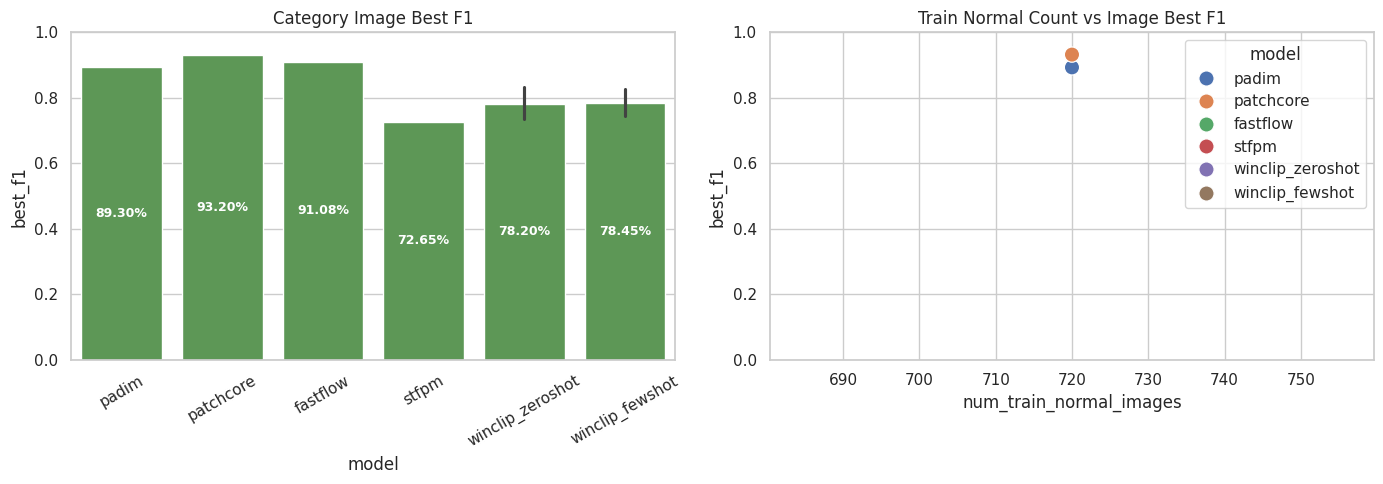

In [ ]:

if len(category_metrics_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=category_metrics_df, x="model", y="best_f1", ax=axes[0], color="#54A24B")
    axes[0].set_title("Category Image Best F1")
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=30)
    annotate_bars_as_percent(axes[0])

    if "num_train_normal_images" in category_metrics_df.columns:
        sns.scatterplot(
            data=category_metrics_df,
            x="num_train_normal_images",
            y="best_f1",
            hue="model",
            s=120,
            ax=axes[1],
        )
        axes[1].set_title("Train Normal Count vs Image Best F1")
        axes[1].set_ylim(0, 1)
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
threshold_frames = []
for model_name, run_root in MODEL_RUNS.items():
    path = run_root / "best_test_results" / "threshold_curve.csv"
    df = load_dataframe(path)
    if len(df):
        df["model"] = model_name
        threshold_frames.append(df)

threshold_df = pd.concat(threshold_frames, ignore_index=True) if threshold_frames else pd.DataFrame()
threshold_df.head()


,threshold,precision,recall,f1,tp,fp,fn,tn,model
0,0.307932,0.500000,1.0,0.666667,100,100,0,0,padim
1,0.311410,0.507614,1.0,0.673401,100,97,0,3,padim
2,0.314888,0.512821,1.0,0.677966,100,95,0,5,padim
3,0.318365,0.512821,1.0,0.677966,100,95,0,5,padim
4,0.321843,0.515464,1.0,0.680272,100,94,0,6,padim


,model,threshold,precision,recall,f1
2,patchcore,0.478419,0.905660,0.960000,0.932039
0,fastflow,0.233358,0.858407,0.970000,0.910798
1,padim,0.457475,0.834783,0.960000,0.893023
4,winclip_fewshot,0.495763,0.683408,0.895833,0.775334
5,winclip_zeroshot,0.499836,0.677541,0.900000,0.773085
3,stfpm,0.475921,0.613793,0.890000,0.726531


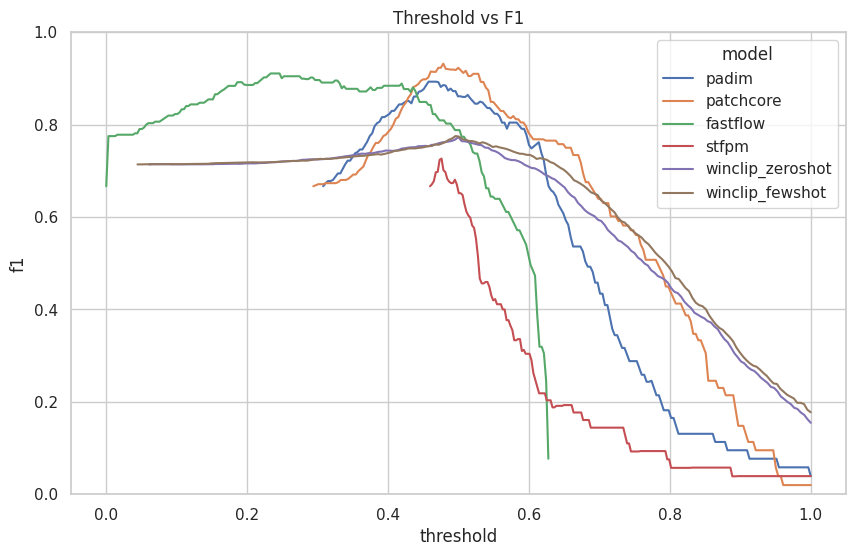

In [ ]:

if len(threshold_df):
    best_points = threshold_df.sort_values(["model", "f1"], ascending=[True, False]).groupby("model", as_index=False).first()
    display(best_points[["model", "threshold", "precision", "recall", "f1"]].sort_values("f1", ascending=False))

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=threshold_df, x="threshold", y="f1", hue="model")
    plt.title("Threshold vs F1")
    plt.ylim(0, 1)
    plt.show()



## Practical Reading Guide

- **best_f1**: 主指標。運用しきい値を決めた後の誤検知と見逃しのバランスを見る。
- **best_precision / best_recall**: best-F1 しきい値での誤検知寄り・見逃し寄りの性格を確認する。
- **threshold curve**: 現場で許容できる recall / precision に合わせて、F1 最大点からしきい値を調整するために使う。
- **image_auroc / image_ap**: しきい値非依存の補助指標。モデルのスコア分離力を見るが、運用比較の主軸にはしない。
- **pixel_auroc / pixel_ap**: 欠陥位置ヒートマップの補助指標。現状 artifact には pixel-level F1 が無いので AUROC/AP を残す。
- **training_cost**: 現場導入時の更新コスト。再学習頻度が高いラインでは重要。
- **inference_cost**: GPU 枚数やスループット制約に直結。
- **ops_fit**: 現場運用のしやすさ。単純な再現性、artifact 管理、再学習の分かりやすさを含む。
- **fewshot_readiness**: 立ち上げ時に正常データが少ないケースへの適性。
